In [2]:
import pandas as pd

train = pd.read_csv("../train.csv")

train.head()

,id,label
0,sample697.npy,7
1,sample54.npy,81
2,sample2270.npy,4
3,sample1401.npy,99
4,sample1901.npy,43


In [3]:
print("Number of training samples:", len(train))

Number of training samples: 2177


In [4]:
print("Number of different labels:", train["label"].nunique())

Number of different labels: 101


In [5]:
label_counts = train["label"].value_counts().sort_index()

print(label_counts)

label
0      19
1      19
2      28
3      18
4      20
       ..
96     19
97     22
98     23
99     21
100    29
Name: count, Length: 101, dtype: int64


In [1]:
print("Hello! My agriculture ML project has started.")

Hello! My agriculture ML project has started.


In [8]:
import os

print(os.listdir("../ot")[:20])

['ot']


In [9]:
import os

print(os.listdir("../ot/ot")[:20])

['sample1.npy', 'sample10.npy', 'sample100.npy', 'sample1000.npy', 'sample1001.npy', 'sample1002.npy', 'sample1003.npy', 'sample1004.npy', 'sample1005.npy', 'sample1006.npy', 'sample1007.npy', 'sample1008.npy', 'sample1009.npy', 'sample101.npy', 'sample1010.npy', 'sample1011.npy', 'sample1012.npy', 'sample1013.npy', 'sample1014.npy', 'sample1015.npy']


In [10]:
import numpy as np

sample = np.load("../ot/ot/sample998.npy")

print("Data type:", type(sample))
print("Shape:", sample.shape)
print("Data type of values:", sample.dtype)

Data type: <class 'numpy.ndarray'>
Shape: (128, 128, 125)
Data type of values: uint16


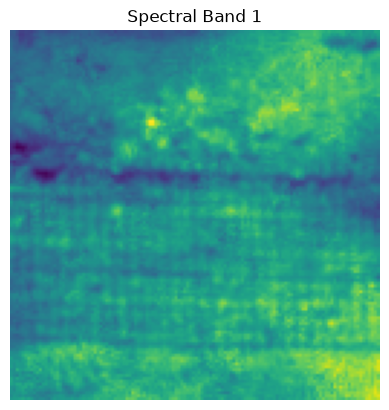

In [11]:
import matplotlib.pyplot as plt

plt.imshow(sample[:, :, 0])
plt.title("Spectral Band 1")
plt.axis("off")
plt.show()

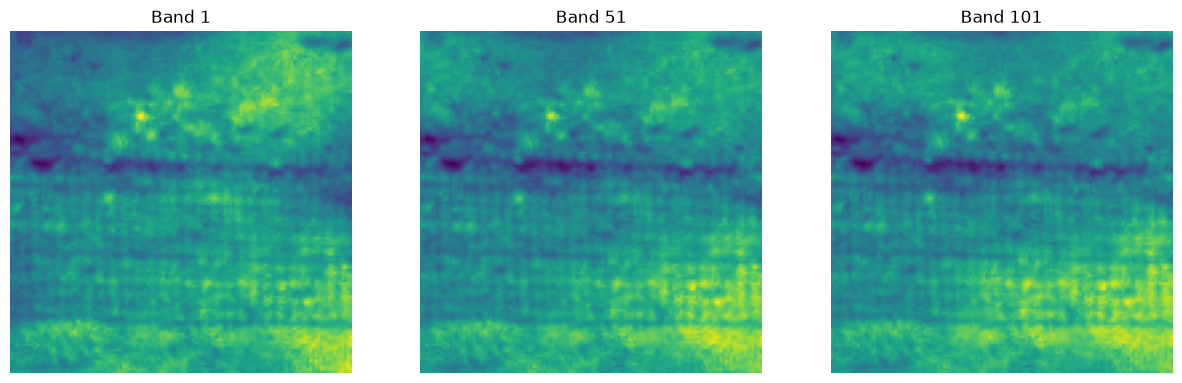

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample[:, :, 0])
axes[0].set_title("Band 1")

axes[1].imshow(sample[:, :, 50])
axes[1].set_title("Band 51")

axes[2].imshow(sample[:, :, 100])
axes[2].set_title("Band 101")

for ax in axes:
    ax.axis("off")

plt.show()

In [13]:
for band in [0, 50, 100]:
    print(
        f"Band {band + 1}: "
        f"min={sample[:, :, band].min()}, "
        f"max={sample[:, :, band].max()}, "
        f"mean={sample[:, :, band].mean():.2f}"
    )

Band 1: min=337, max=1068, mean=723.31
Band 51: min=890, max=2664, mean=1808.91
Band 101: min=1075, max=3306, mean=2257.27


In [14]:
print("Smallest class:", train["label"].value_counts().min())
print("Largest class:", train["label"].value_counts().max())

Smallest class: 9
Largest class: 34


In [15]:
filename = train.iloc[0]["id"]
label = train.iloc[0]["label"]

print("Filename:", filename)
print("Label:", label)

Filename: sample697.npy
Label: 7


In [16]:
import numpy as np
import os

filename = train.iloc[0]["id"]
label = train.iloc[0]["label"]

file_path = os.path.join("../ot/ot", filename)

data = np.load(file_path)

print("Filename:", filename)
print("Label:", label)
print("Data shape:", data.shape)
print("Data type:", data.dtype)

Filename: sample697.npy
Label: 7
Data shape: (128, 128, 125)
Data type: uint16


In [17]:
pixel = data[64, 64, :]

print("Number of spectral values:", len(pixel))
print("First 10 values:", pixel[:10])

Number of spectral values: 125
First 10 values: [1484 1453 1451 1558 1528 1589 1573 1631 1673 1714]


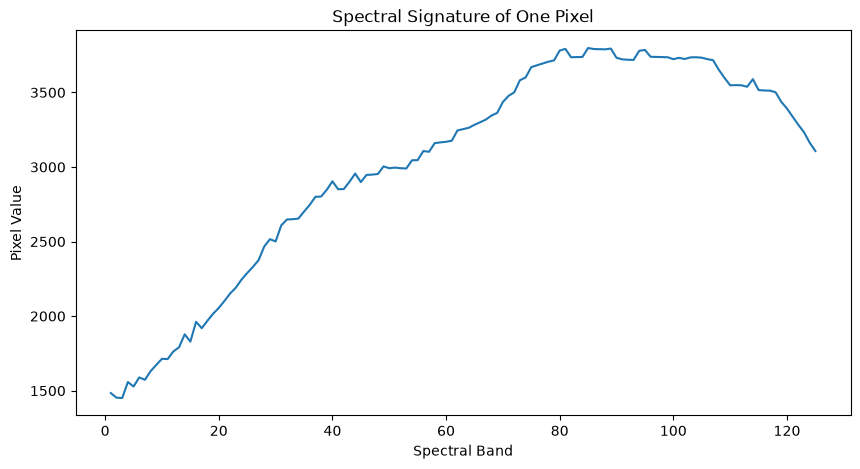

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(range(1, 126), pixel)

plt.xlabel("Spectral Band")
plt.ylabel("Pixel Value")
plt.title("Spectral Signature of One Pixel")

plt.show()

In [20]:
import os
import numpy as np

for i, filename in enumerate(train["id"]):
    file_path = os.path.join("../ot/ot", filename)

    try:
        arr = np.load(file_path)
    except Exception as e:
        print("Problem found!")
        print("Row number:", i)
        print("Filename:", filename)
        print("Error:", type(e).__name__, "-", e)
        break

Problem found!
Row number: 921
Filename: sample2451.npy
Error: ValueError - Failed to read all data for array. Expected (128, 128, 125) = 2048000 elements, could only read 1785856 elements. (file seems not fully written?)


In [22]:
bad_file = "../ot/ot/sample2451.npy"

print("File exists:", os.path.exists(bad_file))
print("File size:", os.path.getsize(bad_file), "bytes")
try:
    bad_data = np.load(bad_file)
    print("Shape:", bad_data.shape)
except Exception as e:
    print("Could not load file:", e)

File exists: True
File size: 3571840 bytes
Could not load file: Failed to read all data for array. Expected (128, 128, 125) = 2048000 elements, could only read 1785856 elements. (file seems not fully written?)


In [23]:
bad_files = []

for i, filename in enumerate(train["id"]):
    file_path = os.path.join("../ot/ot", filename)

    try:
        arr = np.load(file_path)
    except Exception as e:
        bad_files.append((i, filename, str(e)))

print("Number of problematic files:", len(bad_files))

for item in bad_files:
    print(item[0], "-", item[1])

Number of problematic files: 1
921 - sample2451.npy


In [24]:
bad_filename = "sample2451.npy"

clean_train = train[train["id"] != bad_filename].copy()

print("Original samples:", len(train))
print("Clean samples:", len(clean_train))
print("Removed samples:", len(train) - len(clean_train))

Original samples: 2177
Clean samples: 2176
Removed samples: 1


In [25]:
train = pd.read_csv("../train.csv")

print("Rows in train.csv:", len(train))
print("Columns:", train.columns.tolist())
print("First 5 rows:")
display(train.head())

Rows in train.csv: 2177
Columns: ['id', 'label']
First 5 rows:


,id,label
0,sample697.npy,7
1,sample54.npy,81
2,sample2270.npy,4
3,sample1401.npy,99
4,sample1901.npy,43


In [26]:
bad_filename = "sample2451.npy"

clean_train = train[train["id"] != bad_filename].copy()

print("Original samples:", len(train))
print("Clean samples:", len(clean_train))
print("Removed samples:", len(train) - len(clean_train))

Original samples: 2177
Clean samples: 2176
Removed samples: 1


In [ ]:
bad_filename = "sample2451.npy"

clean_train = train[train["id"] != bad_filename].copy()

print("Original samples:", len(train))
print("Clean samples:", len(clean_train))
print("Removed samples:", len(train) - len(clean_train))

Original samples: 2177
Clean samples: 2176
Removed samples: 1


In [27]:
print(clean_train.head())
print("\nClass distribution:")
print(clean_train["label"].value_counts())

print("\nMissing values:")
print(clean_train.isnull().sum())

               id  label
0   sample697.npy      7
1    sample54.npy     81
2  sample2270.npy      4
3  sample1401.npy     99
4  sample1901.npy     43

Class distribution:
label
44    34
21    33
12    31
92    30
66    30
      ..
70    13
48    13
31    12
89    12
10     9
Name: count, Length: 101, dtype: int64

Missing values:
id       0
label    0
dtype: int64


In [28]:
import os
import numpy as np

# Change this if your .npy files are inside another folder
data_dir = "."

missing_files = []
valid_files = []

for filename in clean_train["id"]:
    filepath = os.path.join(data_dir, filename)

    if os.path.exists(filepath):
        valid_files.append(filename)
    else:
        missing_files.append(filename)

print("Total samples:", len(clean_train))
print("Files found:", len(valid_files))
print("Files missing:", len(missing_files))

if missing_files:
    print("\nMissing files:")
    print(missing_files[:20])

Total samples: 2176
Files found: 0
Files missing: 2176

Missing files:
['sample697.npy', 'sample54.npy', 'sample2270.npy', 'sample1401.npy', 'sample1901.npy', 'sample326.npy', 'sample168.npy', 'sample644.npy', 'sample99.npy', 'sample633.npy', 'sample83.npy', 'sample231.npy', 'sample223.npy', 'sample1934.npy', 'sample2352.npy', 'sample1319.npy', 'sample1189.npy', 'sample184.npy', 'sample2694.npy', 'sample2302.npy']


In [29]:
import os

# Show files/folders in your current directory
print("Current directory:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir("."))

Current directory:
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\notebooks

Files and folders:
['01_data_exploration.ipynb']


In [30]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    npy_files = [f for f in files if f.endswith(".npy")]
    
    if npy_files:
        print("Folder:", root)
        print("Number of .npy files:", len(npy_files))
        print("First 10:", npy_files[:10])

In [31]:
import os

project_dir = os.path.dirname(os.getcwd())

print("Project directory:")
print(project_dir)

print("\nFiles and folders:")
print(os.listdir(project_dir))

Project directory:
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025

Files and folders:
['notebooks', 'ot', 'test.csv', 'train.csv']


In [32]:
import os

ot_dir = os.path.join(project_dir, "ot")

print("OT folder:")
print(os.listdir(ot_dir)[:20])

print("\nNumber of items:", len(os.listdir(ot_dir)))

OT folder:
['ot']

Number of items: 1


In [33]:
import os

ot_inner_dir = os.path.join(project_dir, "ot", "ot")

print("Inner OT folder:")
print(os.listdir(ot_inner_dir)[:20])

print("\nNumber of items:", len(os.listdir(ot_inner_dir)))

Inner OT folder:
['sample1.npy', 'sample10.npy', 'sample100.npy', 'sample1000.npy', 'sample1001.npy', 'sample1002.npy', 'sample1003.npy', 'sample1004.npy', 'sample1005.npy', 'sample1006.npy', 'sample1007.npy', 'sample1008.npy', 'sample1009.npy', 'sample101.npy', 'sample1010.npy', 'sample1011.npy', 'sample1012.npy', 'sample1013.npy', 'sample1014.npy', 'sample1015.npy']

Number of items: 2722


In [34]:
npy_files = []

for root, dirs, files in os.walk(ot_inner_dir):
    for file in files:
        if file.endswith(".npy"):
            npy_files.append(os.path.join(root, file))

print("Number of .npy files found:", len(npy_files))

print("\nFirst 10 .npy files:")
for f in npy_files[:10]:
    print(f)

Number of .npy files found: 2722

First 10 .npy files:
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot\sample1.npy
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot\sample10.npy
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot\sample100.npy
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot\sample1000.npy
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot\sample1001.npy
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot\sample1002.npy
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot\sample1003.npy
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot\sample1004.npy
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot\sample1005.npy
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot\sample1006.npy


In [35]:
data_dir = os.path.join(project_dir, "ot", "ot")

print("Data directory:")
print(data_dir)

Data directory:
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\ot\ot


In [36]:
missing_files = []

for filename in clean_train["id"]:
    filepath = os.path.join(data_dir, filename)

    if not os.path.exists(filepath):
        missing_files.append(filename)

print("Training samples:", len(clean_train))
print("Missing training files:", len(missing_files))

if missing_files:
    print("\nMissing files:")
    print(missing_files[:20])

Training samples: 2176
Missing training files: 0


In [37]:
sample_path = os.path.join(data_dir, clean_train.iloc[0]["id"])

sample = np.load(sample_path)

print("File:", clean_train.iloc[0]["id"])
print("Label:", clean_train.iloc[0]["label"])
print("Shape:", sample.shape)
print("Data type:", sample.dtype)
print("Min:", sample.min())
print("Max:", sample.max())

File: sample697.npy
Label: 7
Shape: (128, 128, 125)
Data type: uint16
Min: 200
Max: 4219


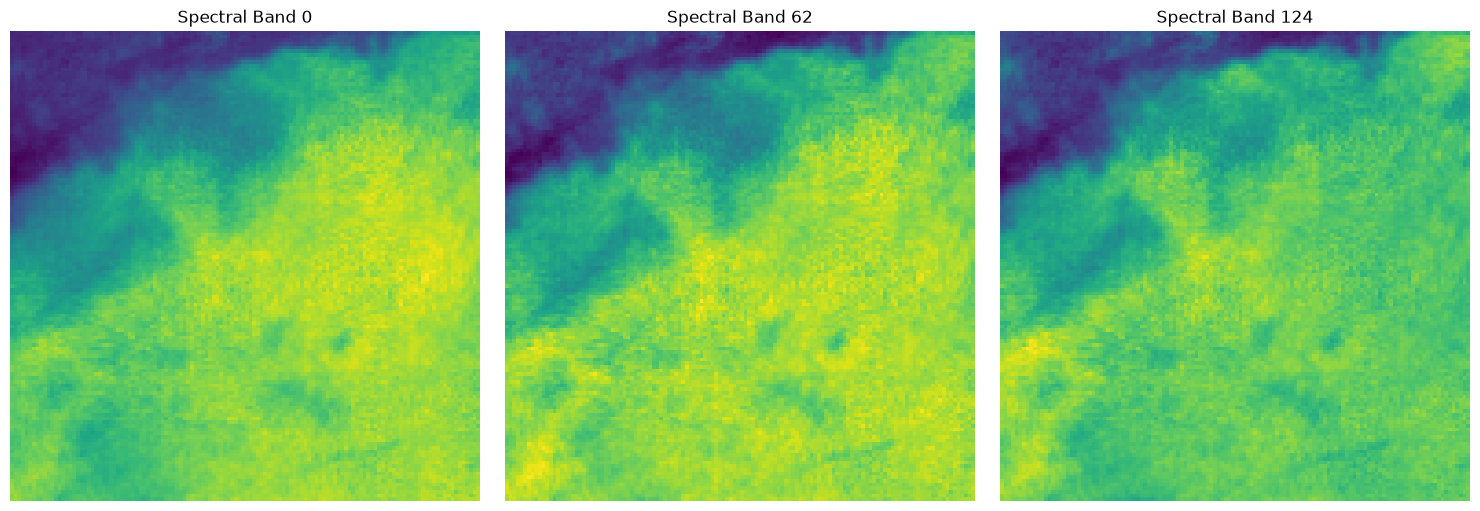

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Load the sample
sample_path = os.path.join(data_dir, clean_train.iloc[0]["id"])
sample = np.load(sample_path)

# Show three spectral bands
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bands = [0, 62, 124]

for ax, band in zip(axes, bands):
    ax.imshow(sample[:, :, band])
    ax.set_title(f"Spectral Band {band}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [39]:
# Calculate the mean intensity of every spectral band
band_means = sample.mean(axis=(0, 1))

print("Number of spectral bands:", len(band_means))
print("First 10 band means:", band_means[:10])
print("Last 10 band means:", band_means[-10:])

Number of spectral bands: 125
First 10 band means: [1200.45324707 1241.20373535 1285.13775635 1324.14233398 1339.60162354
 1351.23132324 1365.33361816 1389.83782959 1437.40722656 1461.30999756]
Last 10 band means: [3135.5657959  3109.71331787 3073.29669189 3032.41357422 2981.82958984
 2923.63830566 2857.11999512 2788.36456299 2718.05310059 2667.10235596]


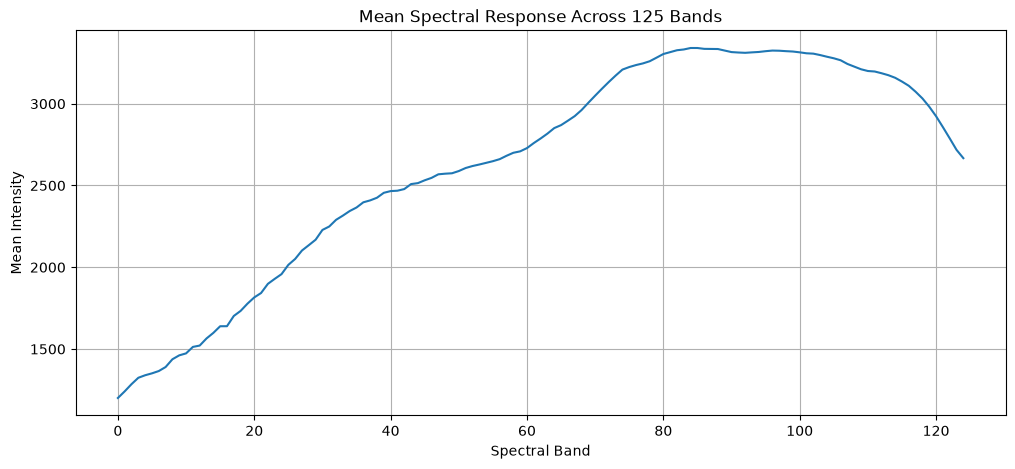

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(range(125), band_means)

plt.xlabel("Spectral Band")
plt.ylabel("Mean Intensity")
plt.title("Mean Spectral Response Across 125 Bands")
plt.grid(True)

plt.show()

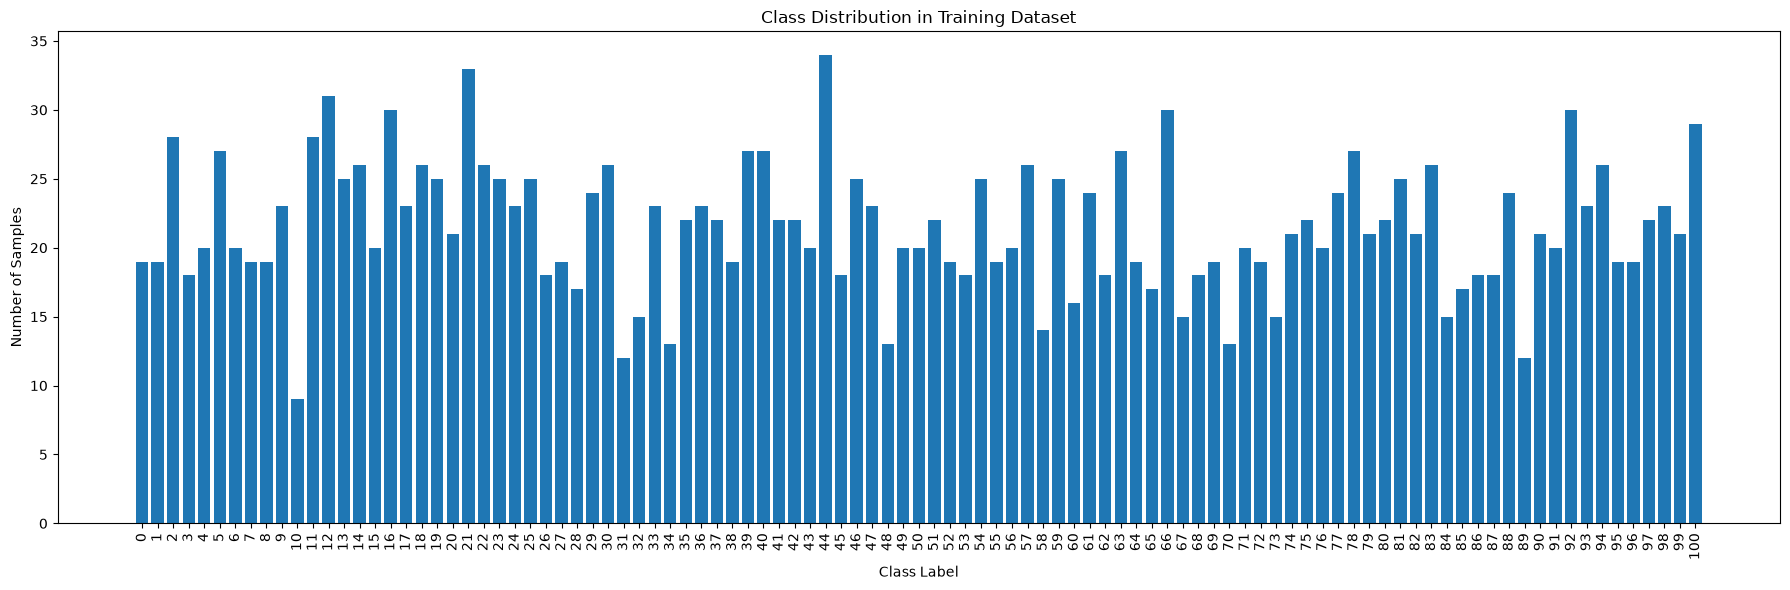

In [41]:
import matplotlib.pyplot as plt

# Count samples in each class
class_counts = clean_train["label"].value_counts().sort_index()

plt.figure(figsize=(18, 6))

plt.bar(class_counts.index.astype(str), class_counts.values)

plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Training Dataset")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [42]:
print("Most represented classes:")
print(class_counts.sort_values(ascending=False).head(10))

print("\nLeast represented classes:")
print(class_counts.sort_values().head(10))

Most represented classes:
label
44     34
21     33
12     31
66     30
16     30
92     30
100    29
11     28
2      28
5      27
Name: count, dtype: int64

Least represented classes:
label
10     9
31    12
89    12
48    13
70    13
34    13
58    14
32    15
67    15
73    15
Name: count, dtype: int64


In [43]:
test = pd.read_csv(os.path.join(project_dir, "test.csv"))

print("Test samples:", len(test))
print("\nTest columns:")
print(test.columns.tolist())

print("\nFirst 5 test rows:")
print(test.head())

print("\nMissing values:")
print(test.isnull().sum())

Test samples: 545

Test columns:
['id']

First 5 test rows:
               id
0  sample1957.npy
1  sample1369.npy
2   sample782.npy
3  sample2255.npy
4  sample2160.npy

Missing values:
id    0
dtype: int64


In [44]:
overlap = set(clean_train["id"]) & set(test["id"])

print("Train samples:", len(clean_train))
print("Test samples:", len(test))
print("Overlapping IDs:", len(overlap))

if overlap:
    print("Overlapping files:", list(overlap)[:20])

Train samples: 2176
Test samples: 545
Overlapping IDs: 0


In [45]:
clean_train.to_csv(
    os.path.join(project_dir, "train_clean.csv"),
    index=False
)

print("Saved cleaned training data.")
print("Rows:", len(clean_train))

Saved cleaned training data.
Rows: 2176


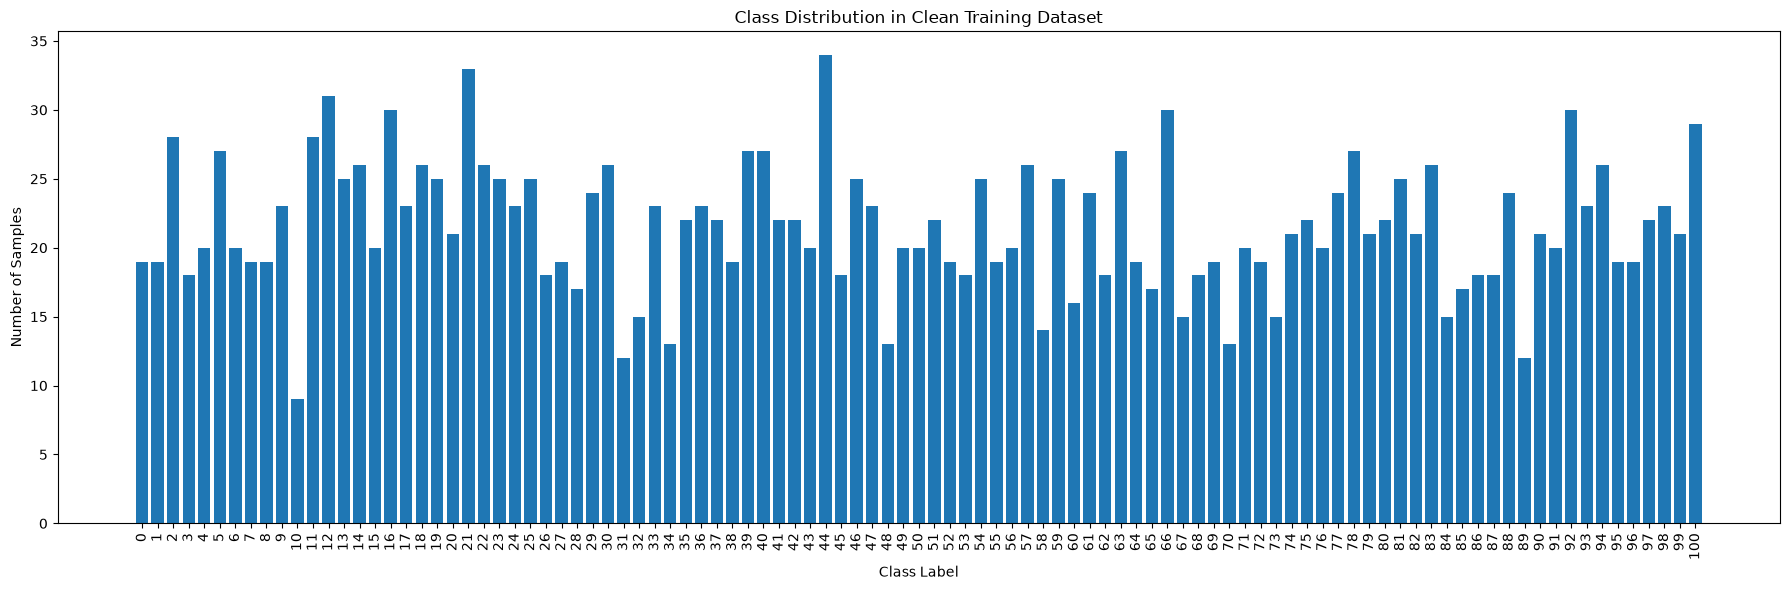

Saved: c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\class_distribution.png


In [46]:
import matplotlib.pyplot as plt

class_counts = clean_train["label"].value_counts().sort_index()

plt.figure(figsize=(18, 6))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Clean Training Dataset")

plt.xticks(rotation=90)
plt.tight_layout()

graph_path = os.path.join(project_dir, "class_distribution.png")
plt.savefig(graph_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", graph_path)

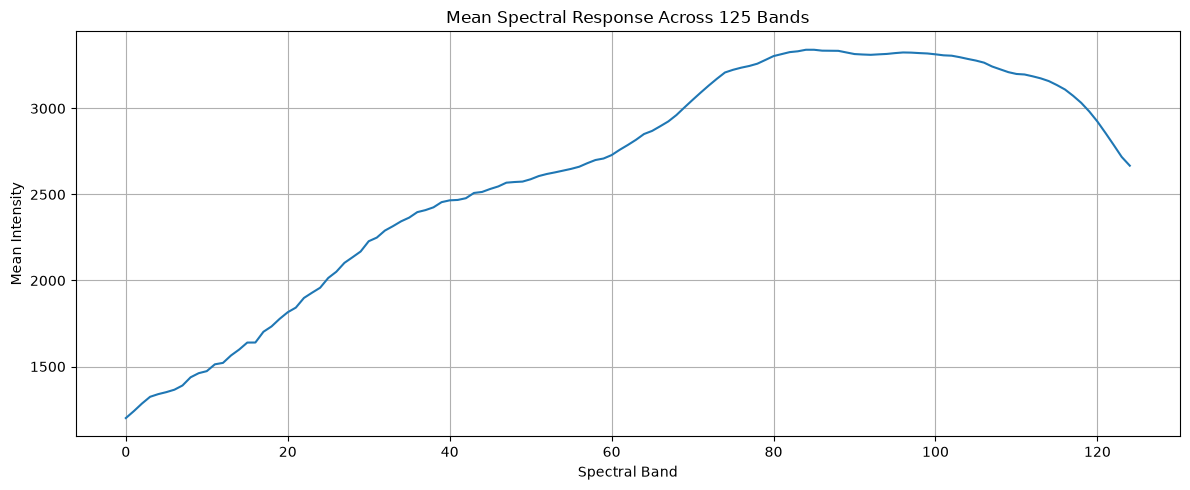

Saved: c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\spectral_response.png


In [47]:
plt.figure(figsize=(12, 5))

plt.plot(range(125), band_means)

plt.xlabel("Spectral Band")
plt.ylabel("Mean Intensity")
plt.title("Mean Spectral Response Across 125 Bands")
plt.grid(True)

plt.tight_layout()

spectral_path = os.path.join(project_dir, "spectral_response.png")
plt.savefig(spectral_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", spectral_path)

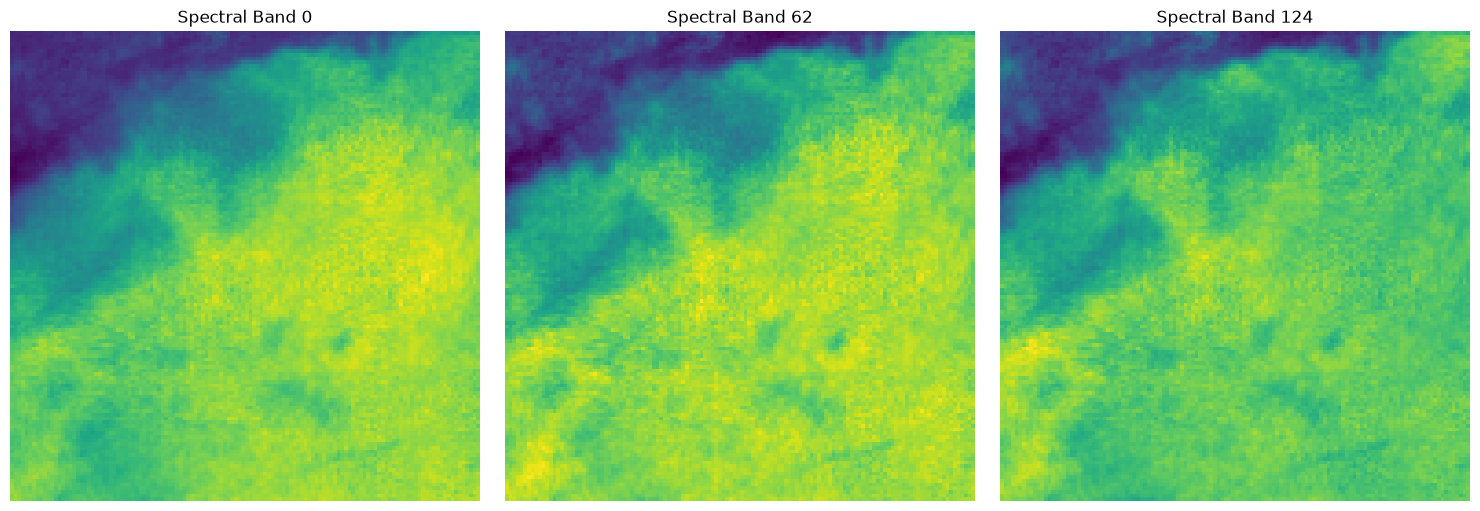

Saved: c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\spectral_bands.png


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bands = [0, 62, 124]

for ax, band in zip(axes, bands):
    ax.imshow(sample[:, :, band])
    ax.set_title(f"Spectral Band {band}")
    ax.axis("off")

plt.tight_layout()

bands_path = os.path.join(project_dir, "spectral_bands.png")
plt.savefig(bands_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", bands_path)

In [49]:
band_means = sample.mean(axis=(0, 1))

In [50]:
import os

clean_path = os.path.join(project_dir, "train_clean.csv")

clean_train.to_csv(clean_path, index=False)

print("Saved file to:")
print(clean_path)

print("\nFile exists:", os.path.exists(clean_path))

Saved file to:
c:\Users\abhi\Downloads\beyond-visible-spectrum-ai-for-agriculture-2025\train_clean.csv

File exists: True
